# Graph 2 - Exercise

Create a Graph where you pass in a single list of integers along with a name and an operation. If the operation is a "+", you add the elements and if it is a "*", you multiply the elements, all within the same node.

**Input**: {"name": "Jack Sparrow","values": [1,2,3,4] , "operation": "*"}

**Output**: "Hi Jack Sparrow, your answer is: 24"

**Hint**: You need an if-statement in your node!

In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [11]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    operation: str
    result: str

In [40]:
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""

    if state["operation"] not in ["+", "*"]:
        raise ValueError("Operation must be either '+' or '*'")

    if state["operation"] == "*":
        total = 1
        for val in state["values"]:
            total *= val
        state["result"] = f"Hi there {state["name"]}! Your product = {total}"

    if state["operation"] == "+":
        state["result"] = f"Hi there {state["name"]}! Yout sum = {sum(state["values"])}"

    return state

In [41]:
graph = StateGraph(AgentState)

graph.add_node("calculator", process_values)
graph.set_entry_point("calculator")
graph.set_finish_point("calculator")

app = graph.compile()

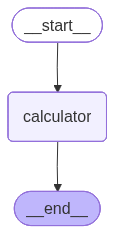

In [42]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
answers = app.invoke({"values" : [1,2,3,4], "name" : "Josiel", "operation" : "*"})
answers["result"]

'Hi there Josiel! Your product = 24'

In [46]:
answers = app.invoke({"values" : [1,2,3,4], "name" : "Josiel", "operation" : "+"})
answers["result"]

'Hi there Josiel! Yout sum = 10'